# This notebook is used to process trait score on December ses 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# data has been extracted from raw firebase files (see psyanim2_analysis for more detail)
# import raw trait data from csv
df_panas = pd.read_csv('./data_extraction/panas_dec_ses2.csv')
df_aq = pd.read_csv('./data_extraction/aq_dec_ses2.csv')
df_ucla = pd.read_csv('./data_extraction/ucla_dec_ses2.csv')
df_ffi = pd.read_csv('./data_extraction/ffi_dec_ses2.csv')
df_fr = pd.read_csv('./data_extraction/fr_dec_ses2.csv')

## Modifying trait scores from text to num

In [3]:
# panas
df_panas_mod = pd.DataFrame()
df_panas_mod = df_panas
df_panas_mod.replace('Very slightly or not at all (1) ', 0, inplace=True)
df_panas_mod.replace('A little (2)', 1, inplace=True)
df_panas_mod.replace('Moderately (3)', 2, inplace=True)
df_panas_mod.replace('Quite a bit (4)', 3, inplace=True)
df_panas_mod.replace('Extremely (5)', 4, inplace=True)
df_panas_mod
# df_panas_mod.to_csv('./trait_analysis/panas_score_converted.csv', index = False)

,Participant ID,1_PANAS_qn0,1_PANAS_qn1,1_PANAS_qn2,1_PANAS_qn3,1_PANAS_qn4,1_PANAS_qn5,1_PANAS_qn6,1_PANAS_qn7,1_PANAS_qn8,...,2_PANAS_qn11,2_PANAS_qn12,2_PANAS_qn13,2_PANAS_qn14,2_PANAS_qn15,2_PANAS_qn16,2_PANAS_qn17,2_PANAS_qn18,2_PANAS_qn19,2_PANAS_qn20
0,172,1,0,0.0,4,0.0,2,0,0.0,0.0,...,1,1,0.0,0,0,1,1.0,0,1,0
1,273,2,1,1.0,4,0.0,1,0,1.0,0.0,...,1,2,0.0,0,2,1,3.0,1,1,1
2,230,1,1,0.0,4,1.0,2,0,1.0,0.0,...,1,3,0.0,0,1,3,2.0,1,2,1
3,101,3,1,2.0,4,0.0,2,0,0.0,0.0,...,0,3,0.0,0,1,0,2.0,2,3,0
4,119,3,0,3.0,4,0.0,3,1,1.0,1.0,...,0,3,1.0,3,0,2,3.0,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,1,0,2.0,4,0.0,2,0,0.0,0.0,...,1,2,0.0,1,1,3,3.0,1,2,0
253,171,3,1,2.0,4,0.0,2,1,0.0,0.0,...,3,2,0.0,1,1,3,2.0,0,3,1
254,238,2,1,1.0,4,1.0,1,1,0.0,2.0,...,3,3,0.0,1,2,2,2.0,3,2,0
255,143,3,0,2.0,4,0.0,2,0,0.0,0.0,...,0,3,0.0,2,0,3,3.0,0,3,0


In [4]:
# aq
df_aq_mod = pd.DataFrame()
df_aq_mod = df_aq
aq_resp = ["Definitely disagree", "Slightly disagree", "Slightly agree", "Definitely agree"]
df_aq_mod.replace('Definitely disagree', 0, inplace=True)
df_aq_mod.replace('Slightly disagree', 1, inplace=True)
df_aq_mod.replace('Slightly agree', 2, inplace=True)
df_aq_mod.replace('Definitely agree', 3, inplace=True)
df_aq_mod
# saving intermediate steps
# df_aq_mod.to_csv('./trait_analysis/aq_score_converted.csv', index = False)

,Participant ID,1_AQ_qn0,1_AQ_qn1,1_AQ_qn2,1_AQ_qn3,1_AQ_qn4,1_AQ_qn5,1_AQ_qn6,1_AQ_qn7,1_AQ_qn8,...,5_AQ_qn41,5_AQ_qn42,5_AQ_qn43,5_AQ_qn44,5_AQ_qn45,5_AQ_qn46,5_AQ_qn47,5_AQ_qn48,5_AQ_qn49,5_AQ_qn50
0,172,0.0,2.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,...,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0,1.0,0.0
1,273,0.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,...,0.0,2.0,0.0,1.0,0.0,3.0,0.0,1.0,0.0,1.0
2,230,1.0,3.0,1.0,3.0,3.0,2.0,2.0,2.0,0.0,...,0.0,3.0,1.0,0.0,1.0,3.0,1.0,1.0,2.0,2.0
3,101,2.0,2.0,3.0,1.0,3.0,2.0,0.0,3.0,0.0,...,0.0,0.0,2.0,1.0,0.0,2.0,2.0,2.0,1.0,2.0
4,119,2.0,1.0,3.0,1.0,1.0,2.0,0.0,1.0,2.0,...,2.0,1.0,2.0,3.0,1.0,1.0,3.0,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,3.0,1.0,2.0,2.0,1.0,1.0,0.0,2.0,2.0,...,0.0,1.0,1.0,2.0,2.0,2.0,2.0,3.0,0.0,3.0
253,171,1.0,0.0,3.0,3.0,1.0,0.0,0.0,3.0,0.0,...,0.0,2.0,2.0,2.0,2.0,3.0,3.0,2.0,3.0,1.0
254,238,1.0,2.0,2.0,2.0,1.0,0.0,0.0,2.0,0.0,...,2.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,3.0,0.0
255,143,2.0,2.0,3.0,1.0,2.0,3.0,0.0,3.0,0.0,...,0.0,1.0,2.0,2.0,0.0,2.0,2.0,2.0,1.0,3.0


In [5]:
# ffi
df_ffi_mod = pd.DataFrame()
df_ffi_mod = df_ffi.copy()
df_ffi_mod.replace('(1) Strongly disagree', 1, inplace=True)
df_ffi_mod.replace('(2) Disagree', 2, inplace=True)
df_ffi_mod.replace('(3) Neutral', 3, inplace=True)
df_ffi_mod.replace('(4) Agree', 4, inplace=True)
df_ffi_mod.replace('(5) Strongly agree', 5, inplace=True)
df_ffi_mod
# df_ffi_mod.to_csv('./trait_analysis/ffi_score_converted.csv', index = False)

,Participant ID,1_ffi_qn0,1_ffi_qn1,1_ffi_qn2,1_ffi_qn3,1_ffi_qn4,1_ffi_qn5,1_ffi_qn6,1_ffi_qn7,1_ffi_qn8,...,6_ffi_qn51,6_ffi_qn52,6_ffi_qn53,6_ffi_qn54,6_ffi_qn55,6_ffi_qn56,6_ffi_qn57,6_ffi_qn58,6_ffi_qn59,6_ffi_qn60
0,172,5,3,3,5,3,2,5.0,4.0,1,...,1.0,3.0,4,3.0,1.0,3,2,4,1.0,2
1,273,2,1,2,3,4,3,3.0,5.0,1,...,2.0,2.0,5,1.0,2.0,2,5,4,2.0,3
2,230,2,2,3,5,3,4,4.0,5.0,1,...,4.0,4.0,4,2.0,3.0,4,3,4,3.0,4
3,101,2,3,4,4,4,2,5.0,4.0,2,...,1.0,4.0,4,3.0,2.0,2,2,4,1.0,2
4,119,3,4,3,5,3,2,4.0,4.0,4,...,1.0,5.0,5,3.0,4.0,4,2,5,4.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,3,4,2,5,4,2,5.0,3.0,2,...,3.0,4.0,3,2.0,4.0,2,4,4,4.0,4
253,171,1,4,3,4,5,3,4.0,4.0,1,...,2.0,4.0,5,2.0,2.0,4,4,3,2.0,3
254,238,2,2,3,4,5,3,4.0,4.0,2,...,4.0,2.0,3,4.0,2.0,4,4,4,1.0,4
255,143,2,2,4,5,5,1,5.0,4.0,1,...,NaN,4.0,3,2.0,2.0,3,4,2,2.0,5


In [6]:
#UCLA
df_ucla_mod = pd.DataFrame()
df_ucla_mod = df_ucla.copy()
df_ucla_mod.replace('(1) Never', 1, inplace=True)
df_ucla_mod.replace('(2) Rarely', 2, inplace=True)
df_ucla_mod.replace('(3) Sometimes', 3, inplace=True)
df_ucla_mod.replace('(4) Always', 4, inplace=True)
# df_ucla_mod.to_csv('./trait_analysis/ucla_score_converted.csv', index = False)

## Dealing with reverse coding & subsales

In [7]:
# PANAS: adding the different spectrums in the survey [Positive & Negative]
pos = [1, 3, 6, 10, 11, 13, 15, 17, 18, 20]
neg = [2, 5, 7, 8, 9, 12, 14, 16, 19, 21]
df_panas_rev = pd.DataFrame()
df_panas_rev = df_panas_mod
df_panas_rev['Positive'] = df_panas_rev.iloc[:, pos].sum(axis = 1)
df_panas_rev['Negative'] = df_panas_rev.iloc[:, neg].sum(axis = 1)
df_panas_rev
# df_panas_rev.to_csv('./trait_analysis/panas_subscale.csv', index = False)

,Participant ID,1_PANAS_qn0,1_PANAS_qn1,1_PANAS_qn2,1_PANAS_qn3,1_PANAS_qn4,1_PANAS_qn5,1_PANAS_qn6,1_PANAS_qn7,1_PANAS_qn8,...,2_PANAS_qn13,2_PANAS_qn14,2_PANAS_qn15,2_PANAS_qn16,2_PANAS_qn17,2_PANAS_qn18,2_PANAS_qn19,2_PANAS_qn20,Positive,Negative
0,172,1,0,0.0,4,0.0,2,0,0.0,0.0,...,0.0,0,0,1,1.0,0,1,0,8.0,1.0
1,273,2,1,1.0,4,0.0,1,0,1.0,0.0,...,0.0,0,2,1,3.0,1,1,1,13.0,7.0
2,230,1,1,0.0,4,1.0,2,0,1.0,0.0,...,0.0,0,1,3,2.0,1,2,1,15.0,7.0
3,101,3,1,2.0,4,0.0,2,0,0.0,0.0,...,0.0,0,1,0,2.0,2,3,0,16.0,4.0
4,119,3,0,3.0,4,0.0,3,1,1.0,1.0,...,1.0,3,0,2,3.0,0,4,1,30.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,1,0,2.0,4,0.0,2,0,0.0,0.0,...,0.0,1,1,3,3.0,1,2,0,19.0,3.0
253,171,3,1,2.0,4,0.0,2,1,0.0,0.0,...,0.0,1,1,3,2.0,0,3,1,22.0,7.0
254,238,2,1,1.0,4,1.0,1,1,0.0,2.0,...,0.0,1,2,2,2.0,3,2,0,17.0,13.0
255,143,3,0,2.0,4,0.0,2,0,0.0,0.0,...,0.0,2,0,3,3.0,0,3,0,27.0,0.0


In [8]:
# AQ: reverse coding + adding subscales 
reverse_aq = [1, 3, 8, 10, 11, 14, 15, 17, 24, 25, 27, 28, 29, 30, 31, 32, 34, 37, 38, 39, 41, 45, 48, 49, 50, 51]
df_aq_rev = pd.DataFrame()
df_aq_rev = df_aq_mod
def reverse_code(value, max_value):
    return max_value - value

# Apply the reverse_code function to the specified columns
for col_index in reverse_aq:
    max_value = 3
    df_aq_rev.iloc[:, col_index] = df_aq_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))


social_skill = [1, 11, 13, 15, 22, 37, 45, 46, 48, 49]
attn_switch = [2, 4, 10, 16, 25, 32, 34, 38, 44, 47]
img = [3, 8, 14, 20, 21, 24, 41, 42, 43, 51]
attn_to_det = [5, 6, 9, 12, 19, 23, 28, 29, 30, 50]
comm = [7, 17, 18, 26, 27, 31, 33, 35, 39, 40]
df_aq_rev['social skill'] = df_aq_rev.iloc[:, social_skill].sum(axis = 1)
df_aq_rev['attention switching'] = df_aq_rev.iloc[:, attn_switch].sum(axis = 1)
df_aq_rev['imagination'] = df_aq_rev.iloc[:, img].sum(axis = 1)
df_aq_rev['attention to detail'] = df_aq_rev.iloc[:, attn_to_det].sum(axis = 1)
df_aq_rev['communication'] = df_aq_rev.iloc[:, comm].sum(axis = 1)
df_aq_rev
# df_aq_rev.to_csv('./trait_analysis/aq_subscale.csv', index = False)

,Participant ID,1_AQ_qn0,1_AQ_qn1,1_AQ_qn2,1_AQ_qn3,1_AQ_qn4,1_AQ_qn5,1_AQ_qn6,1_AQ_qn7,1_AQ_qn8,...,5_AQ_qn46,5_AQ_qn47,5_AQ_qn48,5_AQ_qn49,5_AQ_qn50,social skill,attention switching,imagination,attention to detail,communication
0,172,3.0,2.0,3.0,2.0,0.0,2.0,0.0,2.0,1.0,...,3.0,2.0,3.0,2.0,3.0,15.0,10.0,14.0,13.0,10.0
1,273,3.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,...,3.0,3.0,2.0,3.0,2.0,21.0,15.0,8.0,18.0,14.0
2,230,2.0,3.0,2.0,3.0,3.0,2.0,2.0,1.0,0.0,...,3.0,2.0,2.0,1.0,1.0,21.0,20.0,11.0,13.0,15.0
3,101,1.0,2.0,0.0,1.0,3.0,2.0,0.0,0.0,0.0,...,2.0,1.0,1.0,2.0,1.0,8.0,10.0,7.0,15.0,3.0
4,119,1.0,1.0,0.0,1.0,1.0,2.0,0.0,2.0,2.0,...,1.0,0.0,1.0,2.0,1.0,7.0,12.0,11.0,14.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,0.0,1.0,1.0,2.0,1.0,1.0,0.0,1.0,2.0,...,2.0,1.0,0.0,3.0,0.0,8.0,14.0,7.0,15.0,10.0
253,171,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,...,3.0,0.0,1.0,0.0,2.0,11.0,20.0,13.0,7.0,10.0
254,238,2.0,2.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,...,2.0,1.0,2.0,0.0,3.0,11.0,17.0,17.0,7.0,13.0
255,143,1.0,2.0,0.0,1.0,2.0,3.0,0.0,0.0,0.0,...,2.0,1.0,1.0,2.0,0.0,10.0,12.0,6.0,18.0,3.0


In [9]:
#FFI: reverse coding + seperate into subscales 1-5
ffi_rev = [1, 3, 8, 9, 12, 14, 15, 16, 18, 23, 24, 27, 29, 30, 31, 33, 38, 39, 43, 45, 46, 47, 49, 56, 58]

df_ffi_rev = pd.DataFrame()
df_ffi_rev = df_ffi_mod.copy()

def reverse_code(value, max_value):
    return max_value - value

for col_index in ffi_rev:
    max_value = 6
    df_ffi_rev.iloc[:, col_index] = df_ffi_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))
    
neu = [1, 6, 11, 16, 21, 26, 31, 36, 42, 47, 52, 57]
ext = [2, 7, 12, 17, 22, 27, 32, 37, 43, 48, 53, 58]
ope = [3, 8, 13, 18, 23, 28, 33, 38, 44, 49, 54, 59]
agr = [4, 9, 14, 19, 24, 28, 34, 39, 45, 50, 55, 60]
con = [5, 10, 15, 20, 25, 30, 35, 40, 46, 51, 56, 61]

df_ffi_rev['neuroticism'] = df_ffi_rev.iloc[:, neu].sum(axis = 1)
df_ffi_rev['extraversion'] = df_ffi_rev.iloc[:, ext].sum(axis = 1)
df_ffi_rev['openness'] = df_ffi_rev.iloc[:, ope].sum(axis = 1)
df_ffi_rev['agreeableness'] = df_ffi_rev.iloc[:, agr].sum(axis = 1)
df_ffi_rev['conscientiousness'] = df_ffi_rev.iloc[:, con].sum(axis = 1)
df_ffi_rev['total'] = df_ffi_rev[['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']].sum(axis=1)
# df_ffi_rev.to_csv('./trait_analysis/ffi_subscale.csv', index = False)

In [10]:
# UCLA: reverse coding 1-4
ucla_rev = [1,5, 6, 10, 11, 16, 17, 20, 21]

df_ucla_rev = pd.DataFrame()
df_ucla_rev = df_ucla_mod.copy()


for col_index in ucla_rev:
    max_value = 5
    df_ucla_rev.iloc[:, col_index] = df_ucla_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))
exc_col = [0,8]
df_ucla_rev['total'] = df_ucla_rev.drop(df_ucla_rev.columns[exc_col], axis=1).sum(axis=1)
df_ucla_rev
# df_ucla_rev.to_csv('./trait_analysis/ucla_subscale.csv', index = False)

,Participant ID,1_UCLA_qn0,1_UCLA_qn1,1_UCLA_qn2,1_UCLA_qn3,1_UCLA_qn4,1_UCLA_qn5,1_UCLA_qn6,1_UCLA_qn7,1_UCLA_qn8,...,2_UCLA_qn12,2_UCLA_qn13,2_UCLA_qn14,2_UCLA_qn15,2_UCLA_qn16,2_UCLA_qn17,2_UCLA_qn18,2_UCLA_qn19,2_UCLA_qn20,total
0,172,2,1.0,2,1,2,2.0,1,4,1.0,...,1,2.0,1,1.0,2.0,2,3.0,2,2,34.0
1,273,3,3.0,2,3,2,2.0,2,4,3.0,...,3,3.0,3,3.0,3.0,3,1.0,2,2,51.0
2,230,2,2.0,3,3,2,3.0,2,4,3.0,...,2,3.0,2,2.0,3.0,3,3.0,2,2,50.0
3,101,2,1.0,1,1,3,2.0,2,4,3.0,...,1,2.0,2,1.0,2.0,3,1.0,1,1,35.0
4,119,2,1.0,1,1,3,3.0,2,4,2.0,...,3,3.0,2,1.0,2.0,2,2.0,1,1,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,99,2,2.0,2,2,2,2.0,1,4,3.0,...,2,2.0,3,3.0,2.0,3,3.0,1,1,42.0
253,171,2,2.0,2,2,2,2.0,2,4,3.0,...,1,1.0,2,1.0,2.0,3,3.0,1,1,38.0
254,238,2,2.0,3,3,1,2.0,1,4,3.0,...,1,3.0,3,2.0,3.0,2,2.0,3,3,46.0
255,143,1,3.0,3,3,1,2.0,2,4,3.0,...,2,2.0,3,2.0,2.0,2,2.0,2,2,43.0


## Reweigh: dealing with missing resp

In [11]:
# nan mean, reweighed sum, missResp for each subscale
# panas
df_panas_wed = pd.DataFrame()
df_panas_wed = df_panas_rev
df_panas_wed['Positive_nanMean'] = df_panas_wed.iloc[:, pos].mean(axis=1, skipna=True)
df_panas_wed['Negative_nanMean'] = df_panas_wed.iloc[:, neg].mean(axis=1, skipna=True)
df_panas_wed['Positive_numMissResp'] = df_panas_wed.iloc[:, pos].isna().sum(axis = 1)
df_panas_wed['Negative_numMissResp'] = df_panas_wed.iloc[:, neg].isna().sum(axis = 1)

df_panas_wed['Positive_reweigh'] = df_panas_wed['Positive'] * len(pos)/(len(pos)-df_panas_wed['Positive_numMissResp'])
df_panas_wed['Negative_reweigh'] = df_panas_wed['Negative'] * len(neg)/(len(neg)-df_panas_wed['Negative_numMissResp'])

df_panas_wed['Total_numMissResp'] = df_panas_wed.isna().sum(axis=1)
df_panas_wed
# df_panas_wed.to_csv('./trait_analysis/panas_missResp_retest.csv', index = False)

In [12]:
# aq
df_aq_wed = pd.DataFrame()
df_aq_wed = df_aq_rev

# social_skill = [1, 11, 13, 15, 22, 37, 45, 46, 48, 49]
# attn_switch = [2, 4, 10, 16, 25, 32, 34, 38, 44, 47]
# img = [3, 8, 14, 20, 21, 24, 41, 42, 43, 51]
# attn_to_det = [5, 6, 9, 12, 19, 23, 28, 29, 30, 50]
# comm = [7, 17, 18, 26, 27, 31, 33, 35, 39, 40]

df_aq_wed['social_skill_nanMean'] = df_aq_wed.iloc[:, social_skill].mean(axis=1, skipna=True)
df_aq_wed['attn_switch_nanMean'] = df_aq_wed.iloc[:, attn_switch].mean(axis=1, skipna=True)
df_aq_wed['img_nanMean'] = df_aq_wed.iloc[:, img].mean(axis=1, skipna=True)
df_aq_wed['attn_to_det_nanMean'] = df_aq_wed.iloc[:, attn_to_det].mean(axis=1, skipna=True)
df_aq_wed['comm_nanMean'] = df_aq_wed.iloc[:, comm].mean(axis=1, skipna=True)

df_aq_wed['social_skill_numMissResp'] = df_aq_wed.iloc[:, social_skill].isna().sum(axis = 1)
df_aq_wed['attn_switch_numMissResp'] = df_aq_wed.iloc[:, attn_switch].isna().sum(axis = 1)
df_aq_wed['img_numMissResp'] = df_aq_wed.iloc[:, img].isna().sum(axis = 1)
df_aq_wed['attn_to_det_numMissResp'] = df_aq_wed.iloc[:, attn_to_det].isna().sum(axis = 1)
df_aq_wed['comm_numMissResp'] = df_aq_wed.iloc[:, comm].isna().sum(axis = 1)

df_aq_wed['social_skill_reweigh'] = df_aq_wed['social skill'] * len(social_skill)/(len(social_skill)-df_aq_wed['social_skill_numMissResp'])
df_aq_wed['attn_switch_reweigh'] = df_aq_wed['attention switching'] * len(attn_switch)/(len(attn_switch)-df_aq_wed['attn_switch_numMissResp'])
df_aq_wed['img_reweigh'] = df_aq_wed['imagination'] * len(img)/(len(img)-df_aq_wed['img_numMissResp'])
df_aq_wed['attn_to_det_reweigh'] = df_aq_wed['attention to detail'] * len(attn_to_det)/(len(attn_to_det)-df_aq_wed['attn_to_det_numMissResp'])
df_aq_wed['comm_reweigh'] = df_aq_wed['communication'] * len(comm)/(len(comm)-df_aq_wed['comm_numMissResp'])


df_aq_wed['Total_numMissResp'] = df_aq_wed.isna().sum(axis=1)
df_aq_wed

# saving intermediate steps
# df_aq_wed.to_csv('./trait_analysis/aq_missResp_retest.csv', index = False)

In [13]:
# ffi: reweigh
df_ffi_wed = pd.DataFrame()
df_ffi_wed = df_ffi_rev.copy()

df_ffi_wed['neuroticism_nanMean'] = df_ffi_wed.iloc[:, neu].mean(axis=1, skipna=True)
df_ffi_wed['extraversion_nanMean'] = df_ffi_wed.iloc[:, ext].mean(axis=1, skipna=True)
df_ffi_wed['openness_nanMean'] = df_ffi_wed.iloc[:, ope].mean(axis=1, skipna=True)
df_ffi_wed['agreeableness_nanMean'] = df_ffi_wed.iloc[:, agr].mean(axis=1, skipna=True)
df_ffi_wed['conscientiousness_nanMean'] = df_ffi_wed.iloc[:, con].mean(axis=1, skipna=True)



df_ffi_wed['neuroticism_numMissResp'] = df_ffi_wed.iloc[:, neu].isna().sum(axis = 1)
df_ffi_wed['extraversion_numMissResp'] = df_ffi_wed.iloc[:, ext].isna().sum(axis = 1)
df_ffi_wed['openness_numMissResp'] = df_ffi_wed.iloc[:, ope].isna().sum(axis = 1)
df_ffi_wed['agreeableness_numMissResp'] = df_ffi_wed.iloc[:, agr].isna().sum(axis = 1)
df_ffi_wed['conscientiousness_numMissResp'] = df_ffi_wed.iloc[:, con].isna().sum(axis = 1)

df_ffi_wed['neuroticism_reweigh'] = df_ffi_wed['neuroticism'] * len(neu)/(len(neu)-df_ffi_wed['neuroticism_numMissResp'])
df_ffi_wed['extraversion_reweigh'] = df_ffi_wed['extraversion'] * len(ext)/(len(ext)-df_ffi_wed['extraversion_numMissResp'])
df_ffi_wed['openness_reweigh'] = df_ffi_wed['openness'] * len(ope)/(len(ope)-df_ffi_wed['openness_numMissResp'])
df_ffi_wed['agreeableness_reweigh'] = df_ffi_wed['agreeableness'] * len(agr)/(len(agr)-df_ffi_wed['agreeableness_numMissResp'])
df_ffi_wed['conscientiousness_reweigh'] = df_ffi_wed['conscientiousness'] * len(con)/(len(con)-df_ffi_wed['conscientiousness_numMissResp'])


df_ffi_wed['Total_numMissResp'] = df_ffi_wed.isna().sum(axis=1)
df_ffi_wed['total_reweigh'] =df_ffi_wed[['neuroticism_reweigh', 'extraversion_reweigh', 'openness_reweigh', 'agreeableness_reweigh', 'conscientiousness_reweigh']].sum(axis=1)

df_ffi_wed

# saving intermediate steps
# df_ffi_wed.to_csv('./trait_analysis/ffi_missResp_retest.csv', index = False)

In [14]:
# ucla: reweigh
df_ucla_wed = pd.DataFrame()
df_ucla_wed = df_ucla_rev.copy()

ucla = [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

df_ucla_wed['total_nanMean'] = df_ucla_wed.iloc[:, ucla].mean(axis=1, skipna=True)
df_ucla_wed['total_numMissResp'] = df_ucla_wed.iloc[:, ucla].isna().sum(axis = 1)
df_ucla_wed['total_reweigh'] = df_ucla_wed['total'] * len(ucla)/(len(ucla)-df_ucla_wed['total_numMissResp'])

df_ucla_wed

# saving intermediate steps
# df_ucla_wed.to_csv('./trait_analysis/ucla_missResp_retest.csv', index = False)

## Graphing result

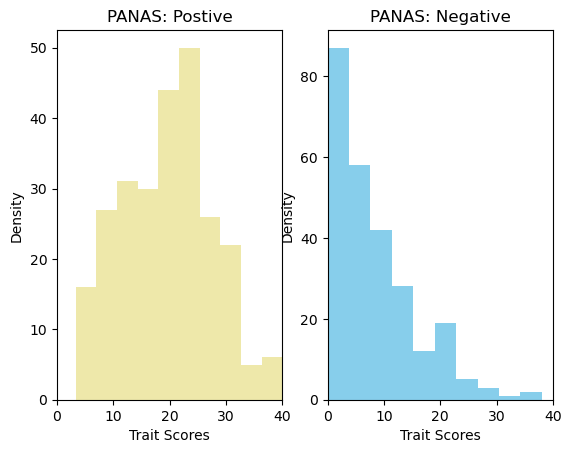

In [15]:
#panas
fig, ax = plt.subplots(1, 2)
ax[0].hist(x=df_panas_wed['Positive_reweigh'], color = 'palegoldenrod')
ax[0].set_title('PANAS: Postive') 
ax[0].set_xlim(0, 40)
ax[0].set_xlabel('Trait Scores')
ax[0].set_ylabel('Density')
ax[1].hist(x=df_panas_wed['Negative_reweigh'], color = 'skyblue')
ax[1].set_title('PANAS: Negative') 
ax[1].set_xlim(0, 40)
ax[1].set_xlabel('Trait Scores')
ax[1].set_ylabel('Density')
plt.savefig('./trait_analysis/panas_dist.png')

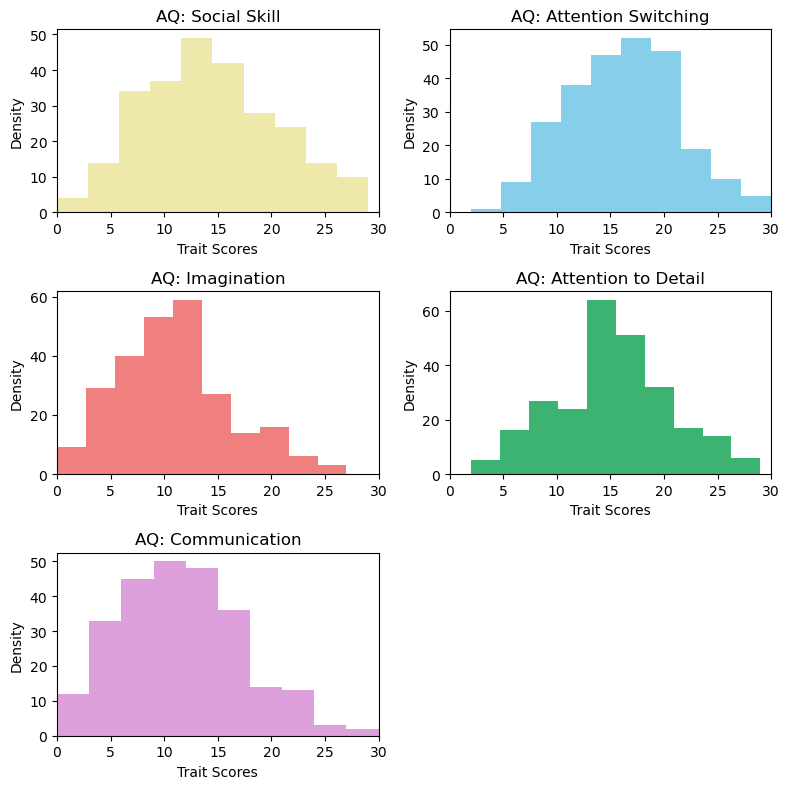

In [20]:
# aq
fig, ax = plt.subplots(3, 2, figsize = (8, 8))
ax[0, 0].hist(x=df_aq_wed['social_skill_reweigh'], color = 'palegoldenrod')
ax[0, 0].set_title('AQ: Social Skill') 
ax[0, 0].set_xlim(0, 30)
ax[0, 0].set_xlabel('Trait Scores')
ax[0, 0].set_ylabel('Density')

ax[0,1].hist(x=df_aq_wed['attn_switch_reweigh'], color = 'skyblue')
ax[0,1].set_title('AQ: Attention Switching') 
ax[0,1].set_xlim(0, 30)
ax[0,1].set_xlabel('Trait Scores')
ax[0,1].set_ylabel('Density')

ax[1,0].hist(x=df_aq_wed['img_reweigh'], color = 'lightcoral')
ax[1,0].set_title('AQ: Imagination') 
ax[1,0].set_xlim(0, 30)
ax[1,0].set_xlabel('Trait Scores')
ax[1,0].set_ylabel('Density')

ax[1,1].hist(x=df_aq_wed['attn_to_det_reweigh'], color = 'mediumseagreen')
ax[1,1].set_title('AQ: Attention to Detail') 
ax[1,1].set_xlim(0, 30)
ax[1,1].set_xlabel('Trait Scores')
ax[1,1].set_ylabel('Density')

ax[2,0].hist(x=df_aq_wed['comm_reweigh'], color = 'plum')
ax[2,0].set_title('AQ: Communication') 
ax[2,0].set_xlim(0, 30)
ax[2,0].set_xlabel('Trait Scores')
ax[2,0].set_ylabel('Density')
ax[2,1].set_visible(False)
plt.tight_layout()
plt.savefig('./trait_analysis/aq_dist.png')
plt.show()


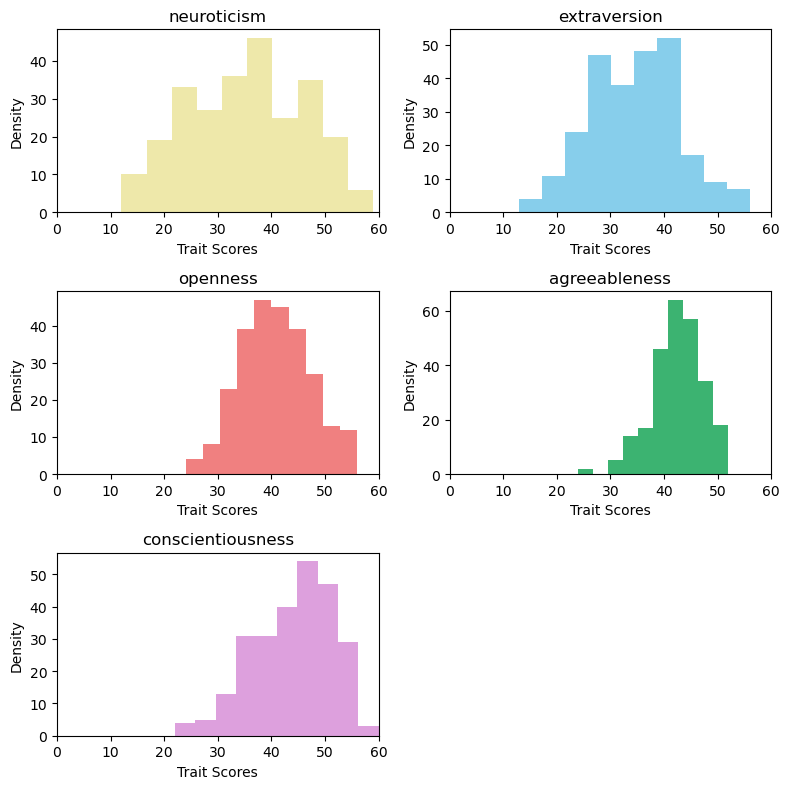

In [17]:
# ffi
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize = (8, 8))
ax[0,0].hist(x=df_ffi_wed['neuroticism_reweigh'], color = 'palegoldenrod')
ax[0,0].set_title('neuroticism') 
ax[0,0].set_xlim(0, 60)
ax[0,0].set_xlabel('Trait Scores')
ax[0,0].set_ylabel('Density')
ax[0,1].hist(x=df_ffi_wed['extraversion_reweigh'], color = 'skyblue')
ax[0,1].set_title('extraversion') 
ax[0,1].set_xlim(0, 60)
ax[0,1].set_xlabel('Trait Scores')
ax[0,1].set_ylabel('Density')
ax[1,0].hist(x=df_ffi_wed['openness_reweigh'], color = 'lightcoral')
ax[1,0].set_title('openness') 
ax[1,0].set_xlim(0, 60)
ax[1,0].set_xlabel('Trait Scores')
ax[1,0].set_ylabel('Density')
ax[1,1].hist(x=df_ffi_wed['agreeableness_reweigh'], color = 'mediumseagreen')
ax[1,1].set_title('agreeableness') 
ax[1,1].set_xlim(0, 60)
ax[1,1].set_xlabel('Trait Scores')
ax[1,1].set_ylabel('Density')
ax[2,0].hist(x=df_ffi_wed['conscientiousness_reweigh'], color = 'plum')
ax[2,0].set_title('conscientiousness') 
ax[2,0].set_xlim(0, 60)
ax[2,0].set_xlabel('Trait Scores')
ax[2,0].set_ylabel('Density')
ax[2,1].set_visible(False)
plt.tight_layout()
plt.savefig('./trait_analysis/ffi_dist.png')

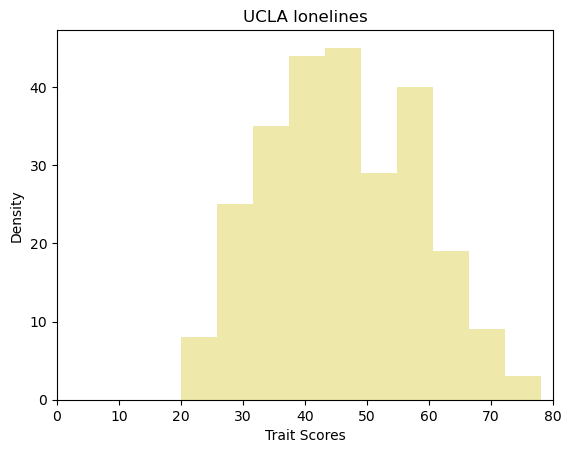

In [18]:
# ucla
plt.hist(x=df_ucla_wed['total_reweigh'], color = 'palegoldenrod')
plt.title('UCLA lonelines') 
plt.xlim(0, 80)
plt.xlabel('Trait Scores')
plt.ylabel('Density')
plt.savefig('./trait_analysis/ucla_dist.png')

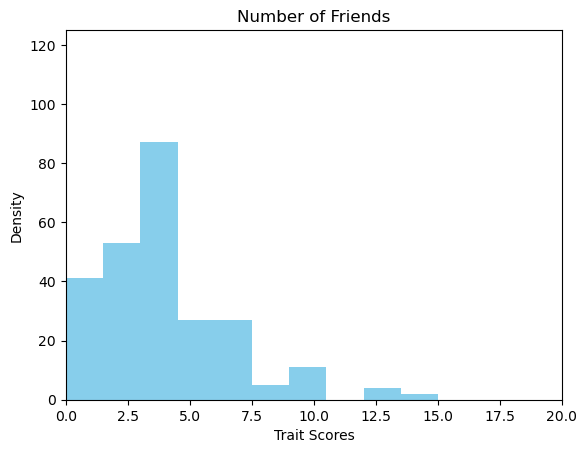

In [19]:
plt.hist(x=df_fr['friend'], color = 'skyblue')
plt.title('Number of Friends') 
plt.xlim(0, 20)
plt.ylim(0, 125)
plt.xlabel('Trait Scores')
plt.ylabel('Density')
plt.savefig('./trait_analysis/fr_dist.png')